In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


from sklearn.metrics import (mean_absolute_error,mean_squared_error)

df = pd.read_csv("../data/processed/processed_data.csv")

df["Date"] = pd.to_datetime(df["Date"])



In [2]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Temperature,Fuel_Price,...,Lag_2,Lag_4,Lag_8,Lag_52,Sales_Roll_Mean_4,Sales_Roll_Std_4,Sales_Roll_Mean_12,Sales_Roll_Std_12,Sales_EMA_4,Sales_EMA_12
0,1,1,2010-02-05,24924.50,0,2010,2,5,42.31,2.572,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN
1,1,1,2010-02-12,46039.49,1,2010,2,6,38.51,2.548,...,NaN,NaN,NaN,NaN,24924.500000,0.000000,24924.500000,0.000000,24924.50000,24924.500000
2,1,1,2010-02-19,41595.55,0,2010,2,7,39.93,2.514,...,24924.50,NaN,NaN,NaN,35481.995000,14930.552614,35481.995000,14930.552614,33370.49600,28172.960000
3,1,1,2010-02-26,19403.54,0,2010,2,8,46.63,2.561,...,46039.49,NaN,NaN,NaN,37519.846667,11131.900957,37519.846667,11131.900957,36660.51760,30237.973846
4,1,1,2010-03-05,21827.90,0,2010,3,9,46.50,2.625,...,41595.55,24924.5,NaN,NaN,32990.770000,12832.106391,32990.770000,12832.106391,29757.72656,28571.137870


In [3]:
df_holt=df.copy()

In [5]:
df_holt= df_holt[["Store","Dept","Date","Weekly_Sales"]]

In [6]:
df_holt.head()

,Store,Dept,Date,Weekly_Sales
0,1,1,2010-02-05,24924.50
1,1,1,2010-02-12,46039.49
2,1,1,2010-02-19,41595.55
3,1,1,2010-02-26,19403.54
4,1,1,2010-03-05,21827.90


In [50]:
df_try=df_holt[(df_holt["Store"]==7) & (df_holt["Dept"]==8)]

In [51]:
df_try.tail()

,Store,Dept,Date,Weekly_Sales
60139,7,8,2012-09-28,14197.03
60140,7,8,2012-10-05,14026.73
60141,7,8,2012-10-12,14533.75
60142,7,8,2012-10-19,14121.14
60143,7,8,2012-10-26,14193.09


In [52]:
df_try=df_try[["Date","Weekly_Sales"]]

In [53]:
df_try.head()

,Date,Weekly_Sales
60001,2010-02-05,14979.64
60002,2010-02-12,14716.32
60003,2010-02-19,14181.70
60004,2010-02-26,14712.90
60005,2010-03-05,15384.75


In [54]:
df_test=df_try[df_try["Date"]>pd.to_datetime("2012-03-01")]


In [55]:
df_train=df_try[df_try["Date"]<=pd.to_datetime("2012-03-01")]


In [56]:
df_train.head()
df_train.shape

(108, 2)

In [57]:
# from statsmodels.tsa.api import ExponentialSmoothing

# model_triple = ExponentialSmoothing(
#     df_train["Weekly_Sales"], 
#     seasonal_periods=12, 
#     trend='add', 
#     seasonal='add')

# model_triple_fit = model_triple.fit()

from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    df_train["Weekly_Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=52
)

fit = model.fit()

c:\Users\Swaraj Shedge\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [58]:
forecast = fit.forecast(34)
print(forecast)

108    14014.200972
109    13562.724839
110    13088.408898
111    13889.374813
112    14236.908477
113    14795.767894
114    12776.773299
115    13573.073037
116    12623.532206
117    12492.191989
118    12349.170932
119    12227.760902
120    12549.240621
121    13100.432297
122    13410.448645
123    13742.528232
124    13030.199525
125    14317.558656
126    14551.665958
127    14371.564723
128    14761.009821
129    14321.063182
130    14774.067306
131    14768.006994
132    14251.293081
133    14074.662780
134    14449.762000
135    14473.662558
136    14295.928907
137    13404.757979
138    13364.302861
139    14499.188689
140    12856.922340
141    13394.368005
dtype: float64


c:\Users\Swaraj Shedge\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [59]:
df_test.head()

,Date,Weekly_Sales
60109,2012-03-02,13721.01
60110,2012-03-09,13965.19
60111,2012-03-16,13018.76
60112,2012-03-23,13030.86
60113,2012-03-30,13129.31


In [60]:
forecast = fit.forecast(len(df_test))

df_results = df_test.copy()
df_results["Forecast"] = forecast.values

print(df_results.head())

            Date  Weekly_Sales      Forecast
60109 2012-03-02      13721.01  14014.200972
60110 2012-03-09      13965.19  13562.724839
60111 2012-03-16      13018.76  13088.408898
60112 2012-03-23      13030.86  13889.374813
60113 2012-03-30      13129.31  14236.908477


c:\Users\Swaraj Shedge\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [61]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(df_results["Weekly_Sales"], df_results["Forecast"])

In [62]:
mae

960.4809635600934

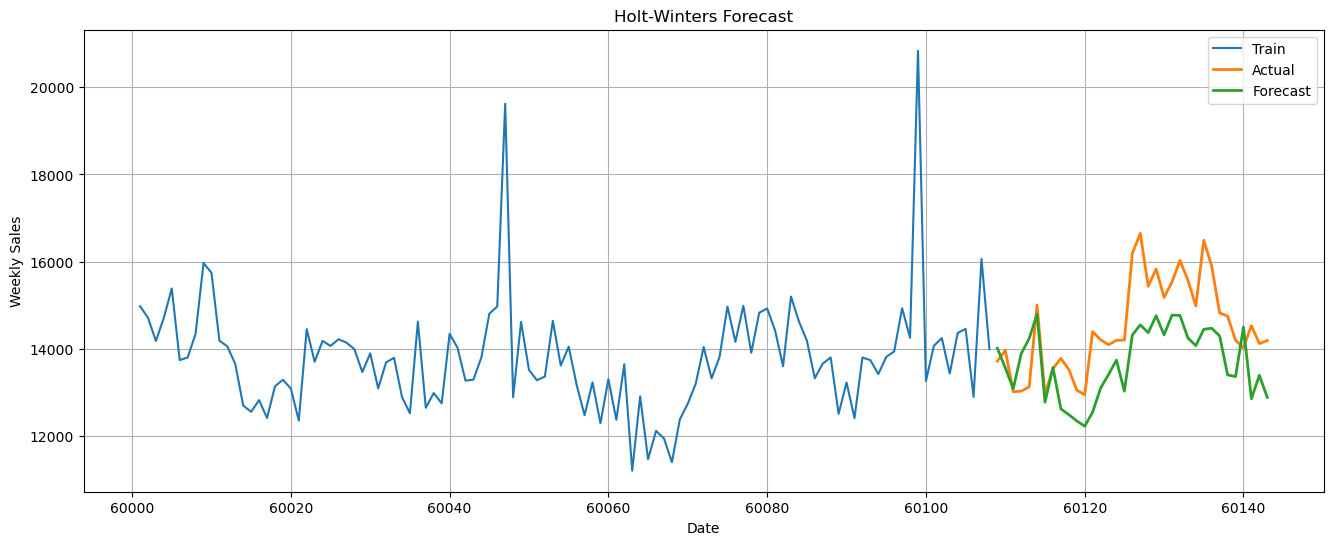

In [63]:
plt.figure(figsize=(16,6))

# Training data
plt.plot(df_train.index, df_train["Weekly_Sales"], label="Train")

# Actual test data
plt.plot(df_test.index, df_test["Weekly_Sales"], label="Actual", linewidth=2)

# Forecast
plt.plot(df_test.index, forecast, label="Forecast", linewidth=2)

plt.title("Holt-Winters Forecast")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(
    data, 
    seasonal_periods=12, 
    trend='add', 
    seasonal='add')

model_triple_fit = model_triple.fit()

# ETS USING statsforecast

In [2]:
pip install statsforecast

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

from statsforecast import StatsForecast
from statsforecast.models import AutoETS

In [4]:
# df_new= df.dropna().copy()
df_new=df.copy()

In [5]:
df_new.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Temperature,Fuel_Price,...,Lag_2,Lag_4,Lag_8,Lag_52,Sales_Roll_Mean_4,Sales_Roll_Std_4,Sales_Roll_Mean_12,Sales_Roll_Std_12,Sales_EMA_4,Sales_EMA_12
0,1,1,2010-02-05,24924.50,0,2010,2,5,42.31,2.572,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN
1,1,1,2010-02-12,46039.49,1,2010,2,6,38.51,2.548,...,NaN,NaN,NaN,NaN,24924.500000,0.000000,24924.500000,0.000000,24924.50000,24924.500000
2,1,1,2010-02-19,41595.55,0,2010,2,7,39.93,2.514,...,24924.50,NaN,NaN,NaN,35481.995000,14930.552614,35481.995000,14930.552614,33370.49600,28172.960000
3,1,1,2010-02-26,19403.54,0,2010,2,8,46.63,2.561,...,46039.49,NaN,NaN,NaN,37519.846667,11131.900957,37519.846667,11131.900957,36660.51760,30237.973846
4,1,1,2010-03-05,21827.90,0,2010,3,9,46.50,2.625,...,41595.55,24924.5,NaN,NaN,32990.770000,12832.106391,32990.770000,12832.106391,29757.72656,28571.137870


In [6]:
df_new.nunique()

Store                     45
Dept                      81
Date                     143
Weekly_Sales          359464
IsHoliday                  2
Year                       3
Month                     12
Week                      52
Temperature             3528
Fuel_Price               892
MarkDown1               2278
MarkDown2               1499
MarkDown3               1662
MarkDown4               1945
MarkDown5               2294
CPI                     2145
Unemployment             349
Size                      40
Type_A                     2
Type_B                     2
Type_C                     2
Lag_1                 357067
Lag_2                 354680
Lag_4                 349906
Lag_8                 340356
Lag_52                232997
Sales_Roll_Mean_4     397868
Sales_Roll_Std_4      413459
Sales_Roll_Mean_12    409714
Sales_Roll_Std_12     414145
Sales_EMA_4           417882
Sales_EMA_12          417948
dtype: int64

In [7]:
df_new.shape

(421570, 32)

In [8]:
df_new = df_new.rename(columns={"Store":"store","Dept":"dept","Date":"ds","Weekly_Sales":"y"})

In [9]:
df_new["unique_id"] = (df_new["store"].astype(str)+ "_"+ df_new["dept"].astype(str))


In [10]:
df_new = df_new[["unique_id","ds","y"]]
df_new.head()

,unique_id,ds,y
0,1_1,2010-02-05,24924.50
1,1_1,2010-02-12,46039.49
2,1_1,2010-02-19,41595.55
3,1_1,2010-02-26,19403.54
4,1_1,2010-03-05,21827.90


In [40]:
# 1. Generate the complete calendar index (weekly on Fridays)
all_dates = pd.date_range(start=df_new['ds'].min(), end=df_new['ds'].max(), freq='W-FRI')
uids = df_new['unique_id'].unique()
full_index = pd.MultiIndex.from_product([uids, all_dates], names=['unique_id', 'ds'])

# 2. Reindex df_new to insert all missing weeks, filling them with 0.1 sales
df_new = df_new.set_index(['unique_id', 'ds']).reindex(full_index, fill_value=0.1).reset_index()

# 3. Print the new shape to confirm gaps are filled
print(f"Data cleaned and filled. New shape: {df_new.shape}")


Data cleaned and filled. New shape: (476333, 3)


In [41]:
df_new["unique_id"].nunique()

3331

In [42]:
df_new[df_new["y"]<0]

,unique_id,ds,y
846,1_6,2012-08-10,-139.65
2405,1_18,2012-05-04,-1.27
6151,1_47,2010-02-19,-863.00
6154,1_47,2010-03-12,-698.00
6184,1_47,2010-10-08,-58.00
...,...,...,...
474189,45_80,2010-02-12,-0.43
474190,45_80,2010-02-19,-0.27
474198,45_80,2010-04-16,-1.61
474209,45_80,2010-07-02,-0.27


In [43]:
# # split_date = "2012-03-01"

# # # 1. Split into train and valid
# # train = df_new[df_new.ds <= split_date].copy()
# # valid = df_new[df_new.ds > split_date].copy()

# split_date = "2012-03-01"

# # 1. Filter the dataset to only evaluate the clean series "1_1"
# df_sample = df_new[df_new['unique_id'] == '1_1'].copy()

# # 2. Split into train and valid sets
# train = df_sample[df_sample.ds <= split_date].copy()
# valid = df_sample[df_sample.ds > split_date].copy()


# # # 2. Filter out non-positive sales (since ETS cannot handle zero or negative values)
# # train = train[train['y'] > 0.1]

# # 3. Filter out series with fewer than 56 data points in the training set (needed for seasonality of 52)
# train_counts = train.groupby('unique_id').size()
# valid_series = train_counts[train_counts >= 56].index
# train = train[train['unique_id'].isin(valid_series)]

# # 4. Filter out constant series (zeros or identical numbers, which cause division by zero in optimization)
# train_vars = train.groupby('unique_id')['y'].var()
# active_series = train_vars[train_vars > 0.01].index
# train = train[train['unique_id'].isin(active_series)]

# # 5. Ensure valid set only contains series that we actually trained on
# valid = valid[valid['unique_id'].isin(train['unique_id'].unique())]


In [44]:
# split_date = "2012-03-01"
## 1 store all dept
# # 1. Filter for all departments in Store 1 (starts with '1_')
# df_sample = df_new[df_new['unique_id'].str.startswith('1_')].copy()

# # 2. Split into train and valid sets
# train = df_sample[df_sample.ds <= split_date].copy()
# valid = df_sample[df_sample.ds > split_date].copy()

# # 3. Clip negative/zero sales to 0.1 (preserves the timeline and supports log/additive math)
# train['y'] = train['y'].clip(lower=0.1)

# # 4. Filter out series with fewer than 56 data points in the training set
# train_counts = train.groupby('unique_id').size()
# valid_series = train_counts[train_counts >= 56].index
# train = train[train['unique_id'].isin(valid_series)]

# # 5. Filter out constant series (variance close to zero)
# train_vars = train.groupby('unique_id')['y'].var()
# active_series = train_vars[train_vars > 0.01].index
# train = train[train['unique_id'].isin(active_series)]

# # 6. Align valid set
# valid = valid[valid['unique_id'].isin(train['unique_id'].unique())]


In [45]:
split_date = "2012-03-01"
# whole dataset
# 1. Split into train and valid sets for the whole dataset
train = df_new[df_new.ds <= split_date].copy()
valid = df_new[df_new.ds > split_date].copy()

# 2. Clip negative/zero sales to 0.1
# train['y'] = train['y'].clip(lower=0.1)


# 3. Filter out series with fewer than 56 data points in the training set
train_counts = train.groupby('unique_id').size()
valid_series = train_counts[train_counts >= 56].index
train = train[train['unique_id'].isin(valid_series)]

# 4. Filter out constant series (variance close to zero)
train_vars = train.groupby('unique_id')['y'].var()
active_series = train_vars[train_vars > 0.01].index
train = train[train['unique_id'].isin(active_series)]

# 5. Align valid set
valid = valid[valid['unique_id'].isin(train['unique_id'].unique())]


In [46]:
train

,unique_id,ds,y
0,1_1,2010-02-05,24924.50
1,1_1,2010-02-12,46039.49
2,1_1,2010-02-19,41595.55
3,1_1,2010-02-26,19403.54
4,1_1,2010-03-05,21827.90
...,...,...,...
476293,45_98,2012-01-27,671.40
476294,45_98,2012-02-03,772.51
476295,45_98,2012-02-10,770.86
476296,45_98,2012-02-17,889.98


In [47]:
# sf = StatsForecast(models=[AutoETS(season_length=52, model="AAA")],freq="W-FRI",n_jobs=-1)

In [48]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, Naive

# 1. Instantiate StatsForecast with Naive as the fallback
sf = StatsForecast(
    models=[AutoETS(season_length=52, model="AAA")],
    freq="W-FRI",
    fallback_model=Naive(),  # If AutoETS fails on any of the 3,000 series, use Naive instead
    n_jobs=-1
)

# 2. Fit the model on the whole dataset
sf.fit(train)
print("Fitting completed successfully for the entire dataset!")


Fitting completed successfully for the entire dataset!


In [49]:
# sf.fit(train)

In [50]:
h = valid["ds"].nunique()

In [51]:
forecast = sf.predict(h=h)
forecast.head()

,unique_id,ds,AutoETS
0,10_1,2012-03-02,33360.356535
1,10_1,2012-03-09,33248.847504
2,10_1,2012-03-16,35001.745917
3,10_1,2012-03-23,48414.304775
4,10_1,2012-03-30,91617.032313


In [52]:
forecast

,unique_id,ds,AutoETS
0,10_1,2012-03-02,33360.356535
1,10_1,2012-03-09,33248.847504
2,10_1,2012-03-16,35001.745917
3,10_1,2012-03-23,48414.304775
4,10_1,2012-03-30,91617.032313
...,...,...,...
115705,9_98,2012-09-28,12.056542
115706,9_98,2012-10-05,12.094715
115707,9_98,2012-10-12,12.184645
115708,9_98,2012-10-19,12.454611


In [53]:
valid

,unique_id,ds,y
108,1_1,2012-03-02,20113.03
109,1_1,2012-03-09,21140.07
110,1_1,2012-03-16,22366.88
111,1_1,2012-03-23,22107.70
112,1_1,2012-03-30,28952.86
...,...,...,...
476328,45_98,2012-09-28,508.37
476329,45_98,2012-10-05,628.10
476330,45_98,2012-10-12,1061.02
476331,45_98,2012-10-19,760.01


In [54]:
results = valid.merge(forecast,on=["unique_id","ds"])
print(results)

       unique_id         ds         y       AutoETS
0            1_1 2012-03-02  20113.03  20165.117858
1            1_1 2012-03-09  21140.07  19454.240400
2            1_1 2012-03-16  22366.88  20485.404823
3            1_1 2012-03-23  22107.70  24484.365453
4            1_1 2012-03-30  28952.86  49859.370860
...          ...        ...       ...           ...
115705     45_98 2012-09-28    508.37   1304.985351
115706     45_98 2012-10-05    628.10   1366.886673
115707     45_98 2012-10-12   1061.02   1371.775508
115708     45_98 2012-10-19    760.01   1494.533708
115709     45_98 2012-10-26   1076.80   1518.652656

[115710 rows x 4 columns]


In [55]:
mae = np.mean(np.abs(results["y"] -results["AutoETS"]))
print(mae)

1556.443061077754


In [56]:
rmse = np.sqrt(np.mean((results["y"]-results["AutoETS"])**2))
print(rmse)

3330.9930360467965


In [57]:
wmape = (np.abs(results["y"]-results["AutoETS"]).sum()/np.abs(results["y"]).sum())*100
print(wmape)
print("Accuracy:",100-wmape)

10.986764444704528
Accuracy: 89.01323555529547


In [58]:
# 1. Generate a complete weekly date range from the start to the end of the dataset
all_dates = pd.date_range(start=df_new['ds'].min(), end=df_new['ds'].max(), freq='W-FRI')
uids = df_new['unique_id'].unique()

# 2. Create a complete Multi-Index of all combinations of unique_id and date
full_index = pd.MultiIndex.from_product([uids, all_dates], names=['unique_id', 'ds'])

# 3. Reindex the dataset. Any missing weeks will be filled with NaN in the sales column 'y'
df_reindexed = df_new.set_index(['unique_id', 'ds']).reindex(full_index).reset_index()

# 4. Filter for the rows that were missing in the original data
missing_weeks = df_reindexed[df_reindexed['y'].isna()]

print(f"Total missing weeks (gaps in timeline): {len(missing_weeks)}")
if len(missing_weeks) > 0:
    print("\nSample of missing weeks (gaps):")
    print(missing_weeks.head(10))


Total missing weeks (gaps in timeline): 0


In [30]:
# Retrieve the fitted models and unique IDs from statsforecast
fitted_models = sf.fitted_
uids = sf.uids  # Corrected from sf.ga.uids to sf.uids

ets_count = 0
fallback_count = 0
failed_series = []

for i, uid in enumerate(uids):
    # Get the fitted model object for each series
    model_obj = fitted_models[i, 0]
    model_name = type(model_obj).__name__
    
    # Check if the fitted model is an ETS model
    if 'ETS' in model_name:
        ets_count += 1
    else:
        fallback_count += 1
        failed_series.append(uid)

print("--- FALLBACK USAGE REPORT ---")
print(f"Total time series:                  {len(uids)}")
print(f"Successfully fitted with AutoETS:   {ets_count} ({ets_count/len(uids)*100:.2f}%)")
print(f"Felled back to Naive:               {fallback_count} ({fallback_count/len(uids)*100:.2f}%)")

if fallback_count > 0:
    print(f"\nSample of series that used the fallback model (showing first 10 out of {fallback_count}):")
    print(failed_series[:10])


--- FALLBACK USAGE REPORT ---
Total time series:                  2936
Successfully fitted with AutoETS:   2928 (99.73%)
Felled back to Naive:               8 (0.27%)

Sample of series that used the fallback model (showing first 10 out of 8):
['13_51', '23_60', '29_51', '32_45', '36_9', '38_20', '5_94', '6_60']


In [31]:
# 1. Extract the training data for the failed series
anomaly_data = train[train['unique_id'] == '13_51'].sort_values('ds')

# 2. Print key mathematical characteristics
print(f"Total weeks of data: {len(anomaly_data)}")
print(f"Variance of sales:   {anomaly_data['y'].var():.4f}")
print(f"Mean of sales:       {anomaly_data['y'].mean():.4f}")
print(f"Number of zeros/0.1: {anomaly_data[anomaly_data['y'] <= 0.11].shape[0]}")
print("\nFirst 15 weeks of sales:")
print(anomaly_data.head(15)[['ds', 'y']])


Total weeks of data: 56
Variance of sales:   1131.4255
Mean of sales:       21.6539
Number of zeros/0.1: 5

First 15 weeks of sales:
               ds      y
124113 2010-02-05  31.58
124114 2010-02-12  25.04
124115 2010-02-19  14.00
124116 2010-02-26  55.52
124117 2010-03-05  23.38
124118 2010-03-12  18.00
124119 2010-03-19  71.00
124120 2010-03-26  65.32
124121 2010-04-02  14.16
124122 2010-04-09 -14.56
124123 2010-04-16  23.64
124124 2010-04-23  10.52
124125 2010-04-30   1.00
124126 2010-05-07  11.08
124127 2010-05-14   6.52


In [32]:
# See the training data for one of the failed series
train[train['unique_id'] == '29_51']


,unique_id,ds,y
282950,29_51,2010-02-05,3.00
282951,29_51,2010-02-12,47.88
282952,29_51,2010-02-19,5.00
282953,29_51,2010-02-26,35.20
282954,29_51,2010-03-05,45.52
282955,29_51,2010-03-12,19.91
282956,29_51,2010-03-26,21.00
282957,29_51,2010-04-02,29.62
282958,29_51,2010-04-09,29.56
282959,29_51,2010-04-16,53.10


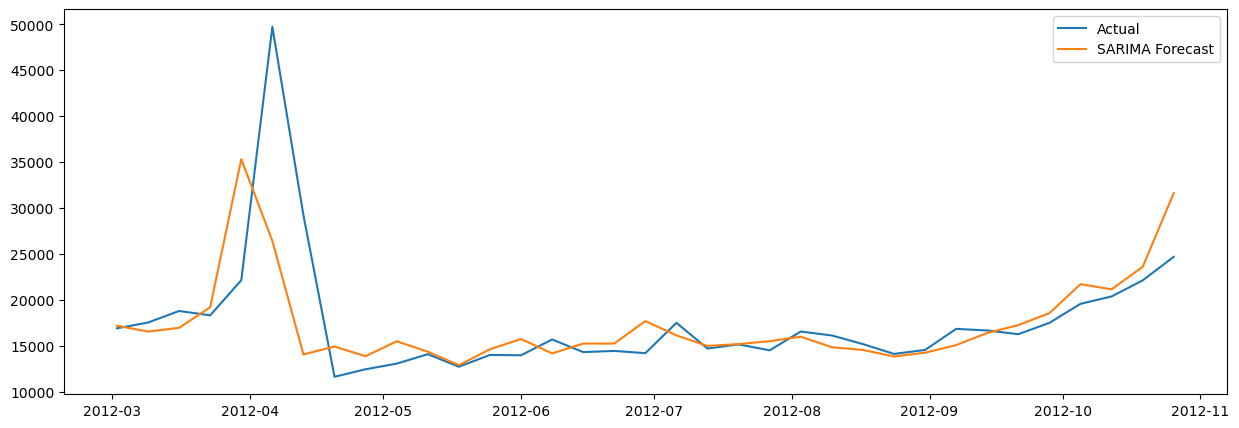

In [33]:
sample = "40_1"

actual = results[
    results["unique_id"] == sample
]

plt.figure(figsize=(15,5))

plt.plot(
    actual["ds"],
    actual["y"],
    label="Actual"
)

plt.plot(
    actual["ds"],
    actual["AutoETS"],
    label="SARIMA Forecast"
)

plt.legend()

plt.show()

In [34]:
# 1. Define a helper function to calculate wMAPE for each series
def calculate_series_wmape(group):
    actual = group['y']
    predicted = group['AutoETS']  # Using the AutoETS predictions
    
    # Avoid division by zero if sales are zero/0.1
    if actual.sum() <= 5: 
        return np.nan
        
    return (np.abs(actual - predicted).sum() / actual.sum()) * 100

# 2. Group by unique_id and apply the wMAPE calculation
series_errors = results.groupby('unique_id').apply(calculate_series_wmape).reset_index(name='wmape')

# 3. Sort by wmape in descending order
worst_series = series_errors.dropna().sort_values(by='wmape', ascending=False)

print("--- WORST PERFORMING STORE-DEPARTMENTS (Highest wMAPE) ---")
print(worst_series.head(15).to_string(index=False))


--- WORST PERFORMING STORE-DEPARTMENTS (Highest wMAPE) ---
unique_id        wmape
     5_59 11755.457306
    43_28  4817.384794
    35_80  4074.044177
     3_59  2942.081344
    43_59  2307.886050
    35_51  2236.472723
    33_25  1470.395990
     7_59  1198.911004
    35_59  1141.244192
    16_59  1062.081118
    22_94   944.916078
    10_59   739.693220
    29_19   719.125903
     7_18   671.718617
    35_54   561.935314


In [35]:
worst_series

,unique_id,wmape
2639,5_59,11755.457306
2375,43_28,4817.384794
1891,35_80,4074.044177
2157,3_59,2942.081344
2385,43_59,2307.886050
...,...,...
1585,31_13,2.824403
220,13_2,2.722464
2312,41_95,2.673334
1683,32_40,2.660734


In [36]:
worst_series[worst_series["wmape"]>100]

,unique_id,wmape
2639,5_59,11755.457306
2375,43_28,4817.384794
1891,35_80,4074.044177
2157,3_59,2942.081344
2385,43_59,2307.886050
...,...,...
36,10_45,102.924570
2435,44_6,102.662669
1043,23_98,102.642886
1963,37_31,102.104851


In [37]:
def diagnose_series(uid, train, results):
    t = train[train["unique_id"] == uid]
    r = results[results["unique_id"] == uid]
    
    return {
        "unique_id": uid,
        "mean_sales": t["y"].mean(),
        "zero_pct": (t["y"] <= 0.11).mean() * 100,
        "cv": t["y"].std() / t["y"].mean() if t["y"].mean() > 0 else np.nan,
        "wmape": (np.abs(r["y"] - r["AutoETS"]).sum() / r["y"].sum()) * 100,
    }

# Run for top 20 worst
worst_ids = worst_series.head(20)["unique_id"].tolist()
diag = pd.DataFrame([diagnose_series(uid, train, results) for uid in worst_ids])
print(diag.sort_values("wmape", ascending=False))

   unique_id    mean_sales  zero_pct        cv         wmape
0       5_59     86.522366  5.376344  1.473653  11755.457306
1      43_28    100.498137  0.980392  0.718758   4817.384794
2      35_80     67.592626  8.080808  1.208321   4074.044177
3       3_59    290.794660  0.970874  1.785172   2942.081344
4      43_59    132.690303  0.000000  0.734353   2307.886050
5      35_51     23.571463  1.219512  1.071215   2236.472723
6      33_25     40.502222  1.234568  0.984066   1470.395990
7       7_59    100.162553  2.127660  0.870923   1198.911004
8      35_59   1048.667944  0.000000  3.049535   1141.244192
9      16_59    126.556105  2.105263  1.007384   1062.081118
10     22_94   1122.425955  1.123596  1.185900    944.916078
11     10_59   2568.555833  0.000000  2.417937    739.693220
12     29_19     44.497857  1.428571  1.490584    719.125903
13      7_18   4898.898947  3.947368  1.502206    671.718617
14     35_54    244.614434  5.660377  1.061634    561.935314
15     34_51     29.8706

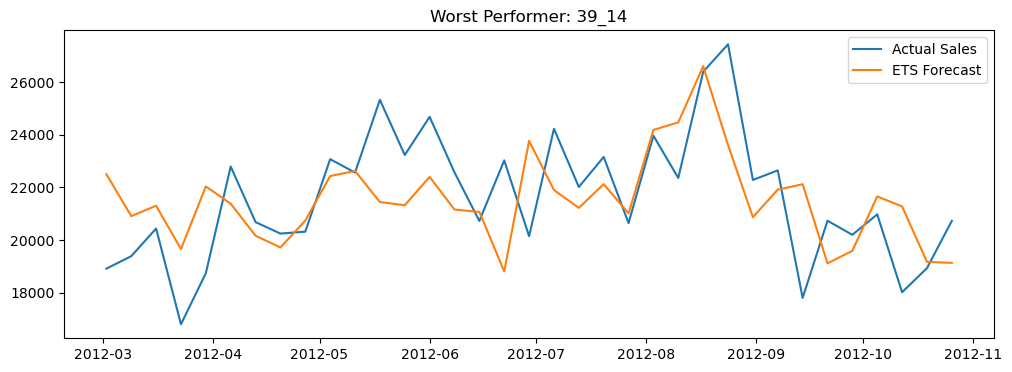

In [38]:
# Plot the worst series (replace 'Store_Dept' with a unique_id from the printed list, e.g. '1_18')
bad_uid = '39_14' 
actual_bad = results[results["unique_id"] == bad_uid]

plt.figure(figsize=(12, 4))
plt.plot(actual_bad["ds"], actual_bad["y"], label="Actual Sales")
plt.plot(actual_bad["ds"], actual_bad["AutoETS"], label="ETS Forecast")
plt.title(f"Worst Performer: {bad_uid}")
plt.legend()
plt.show()


In [39]:
# go through my 05_Model_Comparison.ipynb . i am facing one issue where some of my store dept time series are not working properly . can you tell me how can i fix that 